In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# ============================================================
# GLOBAL FACE AGING DATASET + DATALOADER
# Final version using:
# /content/ffhq_face_attribute_prompts.csv
# ============================================================

import random
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

GLOBAL_IMAGE_DIR = Path("/content/ffhq_subset_6k_extremes_local")
GLOBAL_CSV_PATH = Path("/content/ffhq_face_attribute_prompts.csv")

GLOBAL_RESOLUTION = 512

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}


# ============================================================
# Reproducibility
# ============================================================

def seed_everything(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


# ============================================================
# Basic helpers
# ============================================================

def valid_text(x: Any) -> bool:
    return (
        isinstance(x, str)
        and len(x.strip()) > 0
        and x.strip().lower() not in ["nan", "none", "null"]
    )


def safe_float(x: Any, default: Optional[float] = None) -> Optional[float]:
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default


def clean_gender_label(x: Any) -> Optional[str]:
    if x is None or pd.isna(x):
        return None

    label = str(x).strip().lower()

    if label in ["male", "man", "masculino", "m", "0", "label_0"]:
        return "male"

    if label in ["female", "woman", "femenino", "f", "1", "label_1"]:
        return "female"

    if "female" in label or "woman" in label:
        return "female"

    if "male" in label or "man" in label:
        return "male"

    return None


# ============================================================
# Build image index
# ============================================================

def build_image_index(image_root: Path) -> Dict[str, Path]:
    """
    Builds an index:
        filename -> path
        stem     -> path
    """
    if not image_root.exists():
        raise FileNotFoundError(f"Image directory not found: {image_root}")

    image_paths = [
        p for p in image_root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTS
        and not p.name.startswith("._")
        and "__MACOSX" not in str(p)
    ]

    if len(image_paths) == 0:
        raise FileNotFoundError(f"No images found in: {image_root}")

    index = {}

    for path in image_paths:
        index[path.name] = path
        index[path.stem] = path

    print("[Image index]")
    print("Found image files:", len(image_paths))
    print("Index keys:", len(index))

    return index


global_image_index = build_image_index(GLOBAL_IMAGE_DIR)


# ============================================================
# Prompt builder
# ============================================================

def make_global_prompt_from_attributes(
    age: float,
    gender_label: Any = None,
    gender_confidence: Any = None,
    skin_tone_label: Any = None,
    skin_tone_confidence: Any = None,
    hair_label: Any = None,
    hair_confidence: Any = None,
    glasses_label: Any = None,
    glasses_confidence: Any = None,
    gender_threshold: float = 0.65,
    skin_threshold: float = 0.40,
    hair_threshold: float = 0.35,
    glasses_threshold: float = 0.55,
) -> str:
    """
    Builds final global prompt.

    Gender is included only if gender_confidence >= 0.65.
    Other visual attributes are included only if confidence is high enough.
    """
    age_int = int(round(float(age)))
    age_int = max(0, min(100, age_int))

    gender_confidence = safe_float(gender_confidence, default=None)
    gender_label = clean_gender_label(gender_label)

    if gender_label == "male" and gender_confidence is not None and gender_confidence >= gender_threshold:
        person_phrase = f"a {age_int}-year-old man"
    elif gender_label == "female" and gender_confidence is not None and gender_confidence >= gender_threshold:
        person_phrase = f"a {age_int}-year-old woman"
    else:
        person_phrase = f"a {age_int}-year-old person"

    attr_parts = []

    skin_confidence = safe_float(skin_tone_confidence, default=None)
    if valid_text(skin_tone_label) and skin_confidence is not None and skin_confidence >= skin_threshold:
        attr_parts.append(str(skin_tone_label).strip())

    hair_confidence = safe_float(hair_confidence, default=None)
    if valid_text(hair_label) and hair_confidence is not None and hair_confidence >= hair_threshold:
        attr_parts.append(str(hair_label).strip())

    glasses_confidence = safe_float(glasses_confidence, default=None)
    if (
        valid_text(glasses_label)
        and glasses_confidence is not None
        and glasses_confidence >= glasses_threshold
        and str(glasses_label).strip().lower() == "wearing glasses"
    ):
        attr_parts.append("wearing glasses")

    if len(attr_parts) > 0:
        return "a portrait photo of " + person_phrase + ", " + ", ".join(attr_parts)

    return "a portrait photo of " + person_phrase


# ============================================================
# Build samples from final CSV
# ============================================================

def build_global_samples_from_attribute_csv(
    csv_path: Path,
    image_index: Dict[str, Path],
    filename_col: str = "filename",
    age_col: str = "age_pred",
    min_age: Optional[float] = None,
    max_age: Optional[float] = None,
    require_existing_image: bool = True,
) -> List[Dict[str, Any]]:

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path).copy()

    required_cols = [
        filename_col,
        age_col,
        "gender_label",
        "gender_confidence",
        "skin_tone_label",
        "skin_tone_confidence",
        "hair_label",
        "hair_confidence",
        "glasses_label",
        "glasses_confidence",
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found. Columns: {list(df.columns)}")

    df[age_col] = pd.to_numeric(df[age_col], errors="coerce")
    df = df.dropna(subset=[filename_col, age_col]).reset_index(drop=True)

    if min_age is not None:
        df = df[df[age_col] >= min_age]

    if max_age is not None:
        df = df[df[age_col] <= max_age]

    samples = []
    missing_images = []

    for _, row in df.iterrows():
        filename = str(row[filename_col])
        stem = Path(filename).stem
        age = float(row[age_col])

        image_path = image_index.get(filename, None)
        if image_path is None:
            image_path = image_index.get(Path(filename).name, None)
        if image_path is None:
            image_path = image_index.get(stem, None)

        if image_path is None:
            missing_images.append(filename)

            if require_existing_image:
                continue
            else:
                raise FileNotFoundError(f"Image not found for filename={filename}")

        prompt = make_global_prompt_from_attributes(
            age=age,
            gender_label=row.get("gender_label", None),
            gender_confidence=row.get("gender_confidence", None),
            skin_tone_label=row.get("skin_tone_label", None),
            skin_tone_confidence=row.get("skin_tone_confidence", None),
            hair_label=row.get("hair_label", None),
            hair_confidence=row.get("hair_confidence", None),
            glasses_label=row.get("glasses_label", None),
            glasses_confidence=row.get("glasses_confidence", None),
            gender_threshold=0.65,
            skin_threshold=0.40,
            hair_threshold=0.35,
            glasses_threshold=0.55,
        )

        sample = {
            "filename": filename,
            "stem": stem,
            "image_path": str(image_path),
            "age": age,
            "age_rounded": int(round(age)),
            "age_norm": age / 100.0,
            "prompt": prompt,

            # Metadata useful for debugging
            "gender_pred": row.get("gender_pred", None),
            "gender_label": row.get("gender_label", None),
            "gender_confidence": row.get("gender_confidence", None),
            "skin_tone_label": row.get("skin_tone_label", None),
            "skin_tone_confidence": row.get("skin_tone_confidence", None),
            "hair_label": row.get("hair_label", None),
            "hair_confidence": row.get("hair_confidence", None),
            "glasses_label": row.get("glasses_label", None),
            "glasses_confidence": row.get("glasses_confidence", None),
            "face_attribute_phrase": row.get("face_attribute_phrase", None),
            "enriched_prompt_original": row.get("enriched_prompt", None),
            "error": row.get("error", None),
        }

        samples.append(sample)

    print("\n[Dataset build summary]")
    print("CSV rows after filtering:", len(df))
    print("Matched global samples:", len(samples))
    print("Missing images:", len(missing_images))

    if len(missing_images) > 0:
        print("First missing images:", missing_images[:20])

    print("\n[Prompt check: first 10]")
    for s in samples[:10]:
        print(f"{s['filename']} | conf_gender={s['gender_confidence']} | {s['prompt']}")

    if len(samples) == 0:
        raise ValueError("No valid global samples were created.")

    return samples


global_samples = build_global_samples_from_attribute_csv(
    csv_path=GLOBAL_CSV_PATH,
    image_index=global_image_index,
    filename_col="filename",
    age_col="age_pred",
    min_age=None,
    max_age=None,
    require_existing_image=True,
)


# ============================================================
# Dataset
# ============================================================

class GlobalAgingFaceDataset(Dataset):
    """
    Dataset for global face aging branch.

    One item = one full-face image.

    Returned:
        pixel_values: [3, resolution, resolution], normalized to [-1, 1]
        age: apparent age, float
        age_norm: apparent age / 100
        prompt: final controlled prompt
        filename: image filename
    """

    def __init__(
        self,
        samples: List[Dict[str, Any]],
        resolution: int = 512,
        train: bool = True,
        normalize_for_diffusion: bool = True,
    ):
        self.samples = samples
        self.resolution = int(resolution)
        self.train = bool(train)
        self.normalize_for_diffusion = bool(normalize_for_diffusion)

        if len(self.samples) == 0:
            raise ValueError("Global dataset has zero samples.")

        if train:
            transform_list = [
                transforms.Resize(
                    (self.resolution, self.resolution),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                ),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.035,
                            contrast=0.035,
                            saturation=0.025,
                            hue=0.004,
                        )
                    ],
                    p=0.25,
                ),
                transforms.ToTensor(),
            ]
        else:
            transform_list = [
                transforms.Resize(
                    (self.resolution, self.resolution),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                ),
                transforms.ToTensor(),
            ]

        if self.normalize_for_diffusion:
            transform_list.append(
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            )

        self.transform = transforms.Compose(transform_list)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        pixel_values = self.transform(image)

        age = float(sample["age"])
        prompt = sample["prompt"]

        return {
            "pixel_values": pixel_values,
            "age": torch.tensor(age, dtype=torch.float32),
            "age_norm": torch.tensor(age / 100.0, dtype=torch.float32),
            "prompt": prompt,
            "filename": sample["filename"],
            "stem": sample["stem"],
            "image_path": sample["image_path"],
            "gender_label": sample.get("gender_label", None),
            "gender_confidence": sample.get("gender_confidence", None),
        }


# ============================================================
# Collate functions
# ============================================================

def global_train_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch], dim=0),
        "age": torch.stack([b["age"] for b in batch], dim=0),
        "age_norm": torch.stack([b["age_norm"] for b in batch], dim=0),
        "prompt": [b["prompt"] for b in batch],
    }


def global_debug_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch], dim=0),
        "age": torch.stack([b["age"] for b in batch], dim=0),
        "age_norm": torch.stack([b["age_norm"] for b in batch], dim=0),
        "prompt": [b["prompt"] for b in batch],
        "filename": [b["filename"] for b in batch],
        "stem": [b["stem"] for b in batch],
        "image_path": [b["image_path"] for b in batch],
        "gender_label": [b["gender_label"] for b in batch],
        "gender_confidence": [b["gender_confidence"] for b in batch],
    }


# ============================================================
# Create datasets and loaders
# ============================================================

global_train_dataset = GlobalAgingFaceDataset(
    samples=global_samples,
    resolution=GLOBAL_RESOLUTION,
    train=True,
    normalize_for_diffusion=True,
)

global_debug_dataset = GlobalAgingFaceDataset(
    samples=global_samples,
    resolution=GLOBAL_RESOLUTION,
    train=False,
    normalize_for_diffusion=True,
)

global_train_loader = DataLoader(
    global_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=global_train_collate_fn,
    pin_memory=True,
)

global_debug_loader = DataLoader(
    global_debug_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=global_debug_collate_fn,
    pin_memory=True,
)


# ============================================================
# Sanity check
# ============================================================

debug_batch = next(iter(global_debug_loader))

print("\n[Batch check]")
print("pixel_values:", debug_batch["pixel_values"].shape)
print("age:", debug_batch["age"].shape)
print("age_norm:", debug_batch["age_norm"].shape)
print("prompt example:", debug_batch["prompt"][0])
print("gender label example:", debug_batch["gender_label"][0])
print("gender confidence example:", debug_batch["gender_confidence"][0])
print("filename example:", debug_batch["filename"][0])

[Image index]
Found image files: 5542
Index keys: 11084

[Dataset build summary]
CSV rows after filtering: 5542
Matched global samples: 5542
Missing images: 0

[Prompt check: first 10]
00032.png | conf_gender=0.5404380559921265 | a portrait photo of a 47-year-old person, medium skin tone, blonde hair
00044.png | conf_gender=0.5135192275047302 | a portrait photo of a 52-year-old person, medium skin tone, blonde hair
00055.png | conf_gender=0.5169636607170105 | a portrait photo of a 19-year-old person, medium skin tone, brown hair
00075.png | conf_gender=0.7086560130119324 | a portrait photo of a 46-year-old man, medium skin tone, black hair
00084.png | conf_gender=0.5428204536437988 | a portrait photo of a 70-year-old person, medium skin tone, blonde hair, wearing glasses
00088.png | conf_gender=0.598809540271759 | a portrait photo of a 74-year-old person, medium skin tone, gray hair
00110.png | conf_gender=0.6418555378913879 | a portrait photo of a 22-year-old person, medium skin tone,

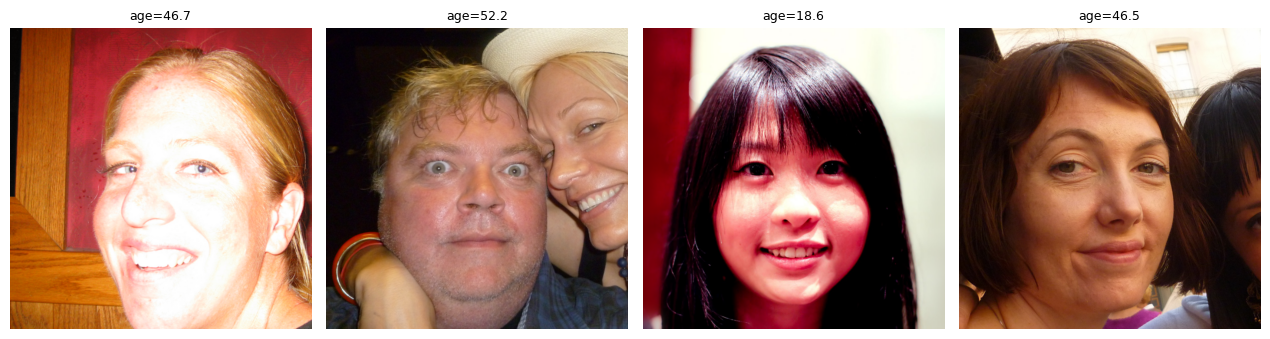


[Prompts]
0: a portrait photo of a 47-year-old person, medium skin tone, blonde hair
1: a portrait photo of a 52-year-old person, medium skin tone, blonde hair
2: a portrait photo of a 19-year-old person, medium skin tone, brown hair
3: a portrait photo of a 46-year-old man, medium skin tone, black hair


In [24]:
# ============================================================
# Visualization
# ============================================================

def denorm_for_plot(x: torch.Tensor) -> torch.Tensor:
    return (x * 0.5 + 0.5).clamp(0, 1)


def show_global_batch(batch: Dict[str, Any], n: int = 4):
    n = min(n, batch["pixel_values"].shape[0])

    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.5))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img = denorm_for_plot(batch["pixel_values"][i]).permute(1, 2, 0).cpu().numpy()
        age = batch["age"][i].item()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"age={age:.1f}", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n[Prompts]")
    for i in range(n):
        print(f"{i}: {batch['prompt'][i]}")

debug_batch = next(iter(global_debug_loader))
show_global_batch(debug_batch, n=4)

In [17]:
# ============================================================
# INCREMENTAL FACE ATTRIBUTE PSEUDO-LABELING
# Only runs Hugging Face on images not already enriched
# ============================================================

!pip -q install transformers accelerate timm einops

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
import torch
from transformers import pipeline


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

GLOBAL_IMAGE_DIR = Path("/content/ffhq_subset_6k_extremes_local")

# Full base CSV with all images and age predictions
BASE_CSV_PATH = Path("/content/ffhq_predictions.csv")

# Existing enriched CSV, partial or complete
ENRICHED_CSV_PATH = Path("/content/ffhq_face_attribute_prompts.csv")

# Same file will be updated incrementally
OUT_CSV_PATH = ENRICHED_CSV_PATH

# Optional: save the subset that was newly processed
NEW_ROWS_CSV_PATH = Path("/content/ffhq_face_attribute_prompts_new_rows.csv")

# Optional: save images still missing from disk
MISSING_IMAGES_CSV_PATH = Path("/content/ffhq_missing_images_for_attribute_prompting.csv")

device = 0 if torch.cuda.is_available() else -1

print("Device:", "cuda" if device == 0 else "cpu")
print("Images:", GLOBAL_IMAGE_DIR)
print("Base CSV:", BASE_CSV_PATH)
print("Existing enriched CSV:", ENRICHED_CSV_PATH)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}


def valid_text(x) -> bool:
    return isinstance(x, str) and len(x.strip()) > 0 and x.strip().lower() not in ["nan", "none", "null"]


def filename_key(x) -> str:
    return Path(str(x).strip()).name


def stem_key(x) -> str:
    return Path(str(x).strip()).stem


def clean_gender_label(raw_label):
    label = str(raw_label).lower()

    if "female" in label or "woman" in label:
        return "female"
    if "male" in label or "man" in label:
        return "male"

    if label in ["label_0", "0"]:
        return "male"
    if label in ["label_1", "1"]:
        return "female"

    return label


def simplify_zero_shot_label(label):
    label = str(label)

    replacements = {
        "a face with light skin tone": "light skin tone",
        "a face with medium skin tone": "medium skin tone",
        "a face with dark skin tone": "dark skin tone",
        "a face with black hair": "black hair",
        "a face with brown hair": "brown hair",
        "a face with blonde hair": "blonde hair",
        "a face with gray hair": "gray hair",
        "a face with white hair": "white hair",
        "a face with red hair": "red hair",
        "a bald or shaved head": "bald or shaved head",
        "a face wearing glasses": "wearing glasses",
        "a face without glasses": "without glasses",
    }

    return replacements.get(label, label)


def top_prediction(preds):
    pred = sorted(preds, key=lambda x: x["score"], reverse=True)[0]
    return pred["label"], float(pred["score"])


def make_enriched_prompt(
    age,
    gender_label=None,
    gender_confidence=None,
    skin_tone_label=None,
    skin_tone_confidence=None,
    hair_label=None,
    hair_confidence=None,
    glasses_label=None,
    glasses_confidence=None,
    gender_threshold=0.70,
    skin_threshold=0.40,
    hair_threshold=0.35,
    glasses_threshold=0.55,
):
    age_int = int(round(float(age)))
    age_int = max(0, min(100, age_int))

    # Gender/sex descriptor
    if gender_label is not None and gender_confidence is not None:
        if gender_confidence >= gender_threshold:
            if gender_label == "male":
                person_phrase = f"a {age_int}-year-old man"
            elif gender_label == "female":
                person_phrase = f"a {age_int}-year-old woman"
            else:
                person_phrase = f"a {age_int}-year-old person"
        else:
            person_phrase = f"a {age_int}-year-old person"
    else:
        person_phrase = f"a {age_int}-year-old person"

    # Visible attributes
    attr_parts = []

    if skin_tone_label is not None and skin_tone_confidence is not None:
        if skin_tone_confidence >= skin_threshold:
            attr_parts.append(skin_tone_label)

    if hair_label is not None and hair_confidence is not None:
        if hair_confidence >= hair_threshold:
            attr_parts.append(hair_label)

    if glasses_label is not None and glasses_confidence is not None:
        if glasses_confidence >= glasses_threshold and glasses_label == "wearing glasses":
            attr_parts.append("wearing glasses")

    if len(attr_parts) > 0:
        return "a portrait photo of " + person_phrase + ", " + ", ".join(attr_parts)

    return "a portrait photo of " + person_phrase


def make_fallback_prompt(age, gender_pred=None):
    age_int = int(round(float(age)))
    age_int = max(0, min(100, age_int))

    gender_label = clean_gender_label(gender_pred)

    if gender_label == "male":
        return f"a portrait photo of a {age_int}-year-old man"
    if gender_label == "female":
        return f"a portrait photo of a {age_int}-year-old woman"

    return f"a portrait photo of a {age_int}-year-old person"


# ------------------------------------------------------------
# Build image index
# ------------------------------------------------------------

image_paths = [
    p for p in GLOBAL_IMAGE_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTS
    and not p.name.startswith("._")
    and "__MACOSX" not in str(p)
]

image_index = {}
for p in image_paths:
    image_index[p.name] = p
    image_index[p.stem] = p

print("\n[Image index]")
print("Found image files:", len(image_paths))
print("Index keys:", len(image_index))


def resolve_image_path(filename):
    filename = str(filename)
    stem = Path(filename).stem
    name = Path(filename).name

    if filename in image_index:
        return image_index[filename]
    if name in image_index:
        return image_index[name]
    if stem in image_index:
        return image_index[stem]

    return None


# ------------------------------------------------------------
# Load base full CSV
# ------------------------------------------------------------

if not BASE_CSV_PATH.exists():
    raise FileNotFoundError(f"Base CSV not found: {BASE_CSV_PATH}")

base_df = pd.read_csv(BASE_CSV_PATH).copy()

if "filename" not in base_df.columns:
    raise ValueError(f"Expected column 'filename'. Found: {list(base_df.columns)}")

if "age_pred" not in base_df.columns:
    raise ValueError(f"Expected column 'age_pred'. Found: {list(base_df.columns)}")

if "gender_pred" not in base_df.columns:
    base_df["gender_pred"] = None

base_df["age_pred"] = pd.to_numeric(base_df["age_pred"], errors="coerce")
base_df = base_df.dropna(subset=["filename", "age_pred"]).reset_index(drop=True)

base_df["filename_key"] = base_df["filename"].apply(filename_key)
base_df["stem_key"] = base_df["filename"].apply(stem_key)
base_df["image_path"] = base_df["filename"].apply(resolve_image_path)

missing_image_df = base_df[base_df["image_path"].isna()].copy()
missing_image_df.to_csv(MISSING_IMAGES_CSV_PATH, index=False)

df_available = base_df.dropna(subset=["image_path"]).reset_index(drop=True)

print("\n[Base CSV]")
print("Base rows:", len(base_df))
print("Rows with local image:", len(df_available))
print("Rows missing local image:", len(missing_image_df))
print("Missing image CSV:", MISSING_IMAGES_CSV_PATH)


# ------------------------------------------------------------
# Load existing enriched CSV and identify already processed
# ------------------------------------------------------------

expected_enriched_cols = [
    "filename",
    "age_pred",
    "gender_label",
    "gender_confidence",
    "skin_tone_label",
    "skin_tone_confidence",
    "hair_label",
    "hair_confidence",
    "glasses_label",
    "glasses_confidence",
    "face_attribute_phrase",
    "enriched_prompt",
    "image_path",
]

if ENRICHED_CSV_PATH.exists():
    existing_df = pd.read_csv(ENRICHED_CSV_PATH).copy()

    if "filename" not in existing_df.columns:
        raise ValueError(
            f"Existing enriched CSV has no 'filename'. Columns: {list(existing_df.columns)}"
        )

    if "enriched_prompt" not in existing_df.columns:
        raise ValueError(
            f"Existing enriched CSV has no 'enriched_prompt'. Columns: {list(existing_df.columns)}"
        )

    existing_df["filename_key"] = existing_df["filename"].apply(filename_key)
    existing_df["stem_key"] = existing_df["filename"].apply(stem_key)

    existing_df["_has_valid_enriched_prompt"] = existing_df["enriched_prompt"].apply(valid_text)

    already_done_stems = set(
        existing_df.loc[existing_df["_has_valid_enriched_prompt"], "stem_key"].astype(str)
    )

    print("\n[Existing enriched CSV]")
    print("Existing rows:", len(existing_df))
    print("Already valid enriched prompts:", len(already_done_stems))

else:
    existing_df = pd.DataFrame(columns=expected_enriched_cols + ["filename_key", "stem_key"])
    already_done_stems = set()

    print("\n[Existing enriched CSV]")
    print("No existing enriched CSV found. Processing all available images.")


# ------------------------------------------------------------
# Keep only images that are not already enriched
# ------------------------------------------------------------

todo_df = df_available[~df_available["stem_key"].astype(str).isin(already_done_stems)].copy()
todo_df = todo_df.reset_index(drop=True)

print("\n[Todo]")
print("Images available:", len(df_available))
print("Already enriched:", len(already_done_stems))
print("Need HF forward:", len(todo_df))

if len(todo_df) == 0:
    print("\n[OK] Nothing new to process. Existing enriched CSV is already up to date.")
else:
    print("\n[First 10 to process]")
    display(todo_df[["filename", "age_pred", "gender_pred", "image_path"]].head(10))


# ------------------------------------------------------------
# Stop early if nothing to process
# ------------------------------------------------------------

if len(todo_df) > 0:

    # ------------------------------------------------------------
    # Load models only if needed
    # ------------------------------------------------------------

    print("\n[Loading models]")

    gender_pipe = pipeline(
        task="image-classification",
        model="syntheticbot/gender-classification-clip",
        device=device,
    )

    zero_shot_pipe = pipeline(
        task="zero-shot-image-classification",
        model="openai/clip-vit-large-patch14",
        device=device,
    )

    # ------------------------------------------------------------
    # Candidate labels
    # ------------------------------------------------------------

    skin_tone_labels = [
        "a face with light skin tone",
        "a face with medium skin tone",
        "a face with dark skin tone",
    ]

    hair_labels = [
        "a face with black hair",
        "a face with brown hair",
        "a face with blonde hair",
        "a face with gray hair",
        "a face with white hair",
        "a face with red hair",
        "a bald or shaved head",
    ]

    glasses_labels = [
        "a face wearing glasses",
        "a face without glasses",
    ]

    # ------------------------------------------------------------
    # Inference loop only on missing rows
    # ------------------------------------------------------------

    new_rows = []

    for _, row in tqdm(todo_df.iterrows(), total=len(todo_df)):
        filename = row["filename"]
        image_path = Path(row["image_path"])
        age = float(row["age_pred"])
        gender_pred = row["gender_pred"] if "gender_pred" in row.index else None

        try:
            image = Image.open(image_path).convert("RGB")

            # Gender
            gender_preds = gender_pipe(image)
            raw_gender_label, gender_conf = top_prediction(gender_preds)
            gender_label = clean_gender_label(raw_gender_label)

            # Skin tone
            skin_preds = zero_shot_pipe(image, candidate_labels=skin_tone_labels)
            raw_skin_label, skin_conf = top_prediction(skin_preds)
            skin_label = simplify_zero_shot_label(raw_skin_label)

            # Hair
            hair_preds = zero_shot_pipe(image, candidate_labels=hair_labels)
            raw_hair_label, hair_conf = top_prediction(hair_preds)
            hair_label = simplify_zero_shot_label(raw_hair_label)

            # Glasses
            glasses_preds = zero_shot_pipe(image, candidate_labels=glasses_labels)
            raw_glasses_label, glasses_conf = top_prediction(glasses_preds)
            glasses_label = simplify_zero_shot_label(raw_glasses_label)

            face_attribute_phrase = ", ".join(
                [
                    x for x in [
                        gender_label if gender_conf >= 0.70 else None,
                        skin_label if skin_conf >= 0.40 else None,
                        hair_label if hair_conf >= 0.35 else None,
                        glasses_label if glasses_conf >= 0.55 and glasses_label == "wearing glasses" else None,
                    ]
                    if x is not None
                ]
            )

            enriched_prompt = make_enriched_prompt(
                age=age,
                gender_label=gender_label,
                gender_confidence=gender_conf,
                skin_tone_label=skin_label,
                skin_tone_confidence=skin_conf,
                hair_label=hair_label,
                hair_confidence=hair_conf,
                glasses_label=glasses_label,
                glasses_confidence=glasses_conf,
            )

            new_rows.append(
                {
                    "filename": filename,
                    "age_pred": age,
                    "gender_pred": gender_pred,
                    "gender_label": gender_label,
                    "gender_confidence": gender_conf,
                    "skin_tone_label": skin_label,
                    "skin_tone_confidence": skin_conf,
                    "hair_label": hair_label,
                    "hair_confidence": hair_conf,
                    "glasses_label": glasses_label,
                    "glasses_confidence": glasses_conf,
                    "face_attribute_phrase": face_attribute_phrase,
                    "enriched_prompt": enriched_prompt,
                    "image_path": str(image_path),
                    "error": None,
                }
            )

        except Exception as e:
            # Important:
            # We do NOT leave prompt empty. We create a safe fallback.
            # But error is stored so you know this row was not truly enriched.
            fallback_prompt = make_fallback_prompt(age=age, gender_pred=gender_pred)

            new_rows.append(
                {
                    "filename": filename,
                    "age_pred": age,
                    "gender_pred": gender_pred,
                    "gender_label": None,
                    "gender_confidence": None,
                    "skin_tone_label": None,
                    "skin_tone_confidence": None,
                    "hair_label": None,
                    "hair_confidence": None,
                    "glasses_label": None,
                    "glasses_confidence": None,
                    "face_attribute_phrase": "",
                    "enriched_prompt": fallback_prompt,
                    "image_path": str(image_path),
                    "error": str(e),
                }
            )

    new_df = pd.DataFrame(new_rows)
    new_df.to_csv(NEW_ROWS_CSV_PATH, index=False)

    print("\n[New rows]")
    print("New rows processed:", len(new_df))
    print("Saved new rows:", NEW_ROWS_CSV_PATH)

    # ------------------------------------------------------------
    # Merge existing + new, deduplicate by stem
    # ------------------------------------------------------------

    # Clean internal columns if present
    existing_clean = existing_df.drop(
        columns=["filename_key", "stem_key", "_has_valid_enriched_prompt"],
        errors="ignore",
    ).copy()

    combined_df = pd.concat([existing_clean, new_df], ignore_index=True)

    combined_df["filename_key"] = combined_df["filename"].apply(filename_key)
    combined_df["stem_key"] = combined_df["filename"].apply(stem_key)

    # Prefer rows without error and with valid enriched_prompt.
    combined_df["_valid_prompt"] = combined_df["enriched_prompt"].apply(valid_text)
    combined_df["_has_error"] = combined_df["error"].notna() if "error" in combined_df.columns else False

    combined_df = combined_df.sort_values(
        by=["stem_key", "_valid_prompt", "_has_error"],
        ascending=[True, False, True],
    )

    combined_df = combined_df.drop_duplicates(subset=["stem_key"], keep="first")

    combined_df = combined_df.drop(
        columns=["filename_key", "stem_key", "_valid_prompt", "_has_error"],
        errors="ignore",
    )

    # Keep a stable column order
    preferred_cols = [
        "filename",
        "age_pred",
        "gender_pred",
        "gender_label",
        "gender_confidence",
        "skin_tone_label",
        "skin_tone_confidence",
        "hair_label",
        "hair_confidence",
        "glasses_label",
        "glasses_confidence",
        "face_attribute_phrase",
        "enriched_prompt",
        "image_path",
        "error",
    ]

    ordered_cols = [c for c in preferred_cols if c in combined_df.columns]
    other_cols = [c for c in combined_df.columns if c not in ordered_cols]
    combined_df = combined_df[ordered_cols + other_cols]

    combined_df.to_csv(OUT_CSV_PATH, index=False)

    print("\n[Updated enriched CSV]")
    print("Saved:", OUT_CSV_PATH)
    print("Total enriched CSV rows:", len(combined_df))
    print("Rows with valid enriched_prompt:", int(combined_df["enriched_prompt"].apply(valid_text).sum()))

    display(combined_df.head(10))

else:
    combined_df = existing_df.drop(
        columns=["filename_key", "stem_key", "_has_valid_enriched_prompt"],
        errors="ignore",
    ).copy()

    print("\n[No update needed]")
    print("Current enriched rows:", len(combined_df))
    display(combined_df.head(10))

Device: cuda
Images: /content/ffhq_subset_6k_extremes_local
Base CSV: /content/ffhq_predictions.csv
Existing enriched CSV: /content/ffhq_face_attribute_prompts.csv

[Image index]
Found image files: 5542
Index keys: 11084

[Base CSV]
Base rows: 19998
Rows with local image: 5542
Rows missing local image: 14456
Missing image CSV: /content/ffhq_missing_images_for_attribute_prompting.csv

[Existing enriched CSV]
Existing rows: 1564
Already valid enriched prompts: 1564

[Todo]
Images available: 5542
Already enriched: 1564
Need HF forward: 3978

[First 10 to process]


,filename,age_pred,gender_pred,image_path
0,00032.png,46.7,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
1,00055.png,18.6,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
2,00142.png,65.8,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
3,00190.png,65.3,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
4,00205.png,39.1,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
5,00206.png,69.4,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
6,00207.png,46.5,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
7,00235.png,31.3,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
8,00259.png,69.7,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...
9,00261.png,47.6,Male,/content/ffhq_subset_6k_extremes_local/ffhq_su...



[Loading models]


Loading weights: 0it [00:00, ?it/s]

CLIPForImageClassification LOAD REPORT from: syntheticbot/gender-classification-clip
Key                                                                         | Status     | 
----------------------------------------------------------------------------+------------+-
vision_model.vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED | 
vision_model.vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTE

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/3978 [00:00<?, ?it/s]


[New rows]
New rows processed: 3978
Saved new rows: /content/ffhq_face_attribute_prompts_new_rows.csv

[Updated enriched CSV]
Saved: /content/ffhq_face_attribute_prompts.csv
Total enriched CSV rows: 5542
Rows with valid enriched_prompt: 5542


,filename,age_pred,gender_pred,gender_label,gender_confidence,skin_tone_label,skin_tone_confidence,hair_label,hair_confidence,glasses_label,glasses_confidence,face_attribute_phrase,enriched_prompt,image_path,error
1564,00032.png,46.7,Male,male,0.540438,medium skin tone,0.588012,blonde hair,0.737491,without glasses,0.945423,"medium skin tone, blonde hair","a portrait photo of a 47-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,None
0,00044.png,52.2,NaN,male,0.513519,medium skin tone,0.828160,blonde hair,0.826774,without glasses,0.580583,"medium skin tone, blonde hair","a portrait photo of a 52-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN
1565,00055.png,18.6,Male,male,0.516964,medium skin tone,0.533744,brown hair,0.358364,without glasses,0.525925,"medium skin tone, brown hair","a portrait photo of a 19-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,None
1,00075.png,46.5,NaN,male,0.708656,medium skin tone,0.701791,black hair,0.619191,without glasses,0.949156,"male, medium skin tone, black hair","a portrait photo of a 46-year-old man, medium ...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN
2,00084.png,70.0,NaN,female,0.542820,medium skin tone,0.496773,blonde hair,0.575414,wearing glasses,0.968589,"medium skin tone, blonde hair, wearing glasses","a portrait photo of a 70-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN
3,00088.png,73.6,NaN,female,0.598810,medium skin tone,0.663390,gray hair,0.798606,without glasses,0.599322,"medium skin tone, gray hair","a portrait photo of a 74-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN
4,00110.png,22.0,NaN,female,0.641856,medium skin tone,0.564377,brown hair,0.494529,without glasses,0.598377,"medium skin tone, brown hair","a portrait photo of a 22-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN
5,00125.png,61.4,NaN,male,0.562509,dark skin tone,0.485062,brown hair,0.890320,wearing glasses,0.937226,"dark skin tone, brown hair, wearing glasses","a portrait photo of a 61-year-old person, dark...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN
1566,00142.png,65.8,Male,male,0.610031,medium skin tone,0.742603,white hair,0.368822,without glasses,0.973753,"medium skin tone, white hair","a portrait photo of a 66-year-old person, medi...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,None
6,00162.png,27.1,NaN,female,0.728604,medium skin tone,0.664310,brown hair,0.760085,wearing glasses,0.648179,"female, medium skin tone, brown hair, wearing ...","a portrait photo of a 27-year-old woman, mediu...",/content/ffhq_subset_6k_extremes_local/ffhq_su...,NaN


In [22]:
combined_df.columns

Index(['filename', 'age_pred', 'gender_pred', 'gender_label',
       'gender_confidence', 'skin_tone_label', 'skin_tone_confidence',
       'hair_label', 'hair_confidence', 'glasses_label', 'glasses_confidence',
       'face_attribute_phrase', 'enriched_prompt', 'image_path', 'error'],
      dtype='object')